# 实验 3：五通道 Beta-Binomial 贝叶斯反馈飞轮

本 Notebook 复现旧版“五通道 Beta-Binomial 贝叶斯自适应收敛（seed=42）”实验，并修正旧图中综合权重只累加到 0.50 的实现错误。

五个 Effect 通道为：探测覆盖、识别准确、拦截成功、OODA 全链路在 5 秒内闭环、低虚警合规（`1-FAR`）。每个通道保留独立 Beta 后验；综合任务满足度定义为：

\[
P(M_{success}\mid D)=\sum_{k=1}^{5} w_k\,\mathbb{E}[p_k\mid D],\qquad \sum_k w_k=1.
\]

该综合量是“随机抽取一项任务要求时的后验满足概率/任务满足度”，不是假设五通道独立后直接相乘的联合成功率。全部结果为固定种子的合成工程仿真，不是现场测试。

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
APP_DIR = PROJECT_ROOT / '03_源码' / 'streamlit_app'
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

OUTPUT_DIR = NOTEBOOK_DIR / '验证输出'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from utils.bayesian_flywheel import (
    CHANNELS,
    COMPOSITE_THRESHOLD,
    audit_flywheel_reproducibility,
    evaluate_fixed_rule_baseline,
    evaluate_ontology_conditioned_counterfactual,
    flywheel_channel_rows,
    simulate_flywheel,
)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('共享模型加载完成:', APP_DIR / 'utils' / 'bayesian_flywheel.py')

共享模型加载完成: D:\Downloads\反无人机体系\智信2026_新概念反无_完整项目包\03_源码\streamlit_app\utils\bayesian_flywheel.py


## 1. 五通道语义、权重与门槛

- 正向通道直接观测“满足任务要求”；虚警率先转换为 `1-FAR`。
- 权重是公开的任务重要度，严格归一化为 1.00。
- OODA 通道不是软件处理延迟，而是“完整闭环时延小于 5 秒”这一事件的满足概率。

In [2]:
channel_spec_table = pd.DataFrame([
    {
        '通道': c.label_zh,
        'Effect 映射': c.source_metric,
        '合成真值': c.true_satisfaction_probability,
        '工程门槛': c.requirement_probability,
        '权重': c.weight,
    }
    for c in CHANNELS
])
weight_sum = channel_spec_table['权重'].sum()
assert np.isclose(weight_sum, 1.0), f'权重和错误: {weight_sum}'
print(f'五通道权重和 = {weight_sum:.2f}')
channel_spec_table

五通道权重和 = 1.00


,通道,Effect 映射,合成真值,工程门槛,权重
0,探测覆盖,DetectionCoverage >= 0.95,0.972,0.95,0.24
1,识别准确,IdentificationAccuracy >= 0.92,0.948,0.92,0.20
2,拦截成功,InterceptionSuccessRate >= 0.85,0.895,0.85,0.24
3,OODA 闭环,P(full-loop latency < 5 s) >= 0.90,0.935,0.90,0.22
4,低虚警合规（1-FAR）,1 - FalseAlarmRate >= 0.98,0.986,0.98,0.10


## 2. 复现 seed=42 贝叶斯自适应收敛图

In [3]:
flywheel = simulate_flywheel(n_observations=200, seed=42)
print(f'终态综合后验 = {flywheel.final_composite:.4f}')
print(f'终态综合 95% CI = [{flywheel.final_composite_interval[0]:.4f}, {flywheel.final_composite_interval[1]:.4f}]')
print(f'首次越过 {COMPOSITE_THRESHOLD:.2f}: n={flywheel.first_threshold_crossing}')
print(f'连续 10 次越过 {COMPOSITE_THRESHOLD:.2f}: n={flywheel.sustained_threshold_crossing}')

终态综合后验 = 0.9459
终态综合 95% CI = [0.9302, 0.9594]
首次越过 0.90: n=44
连续 10 次越过 0.90: n=44


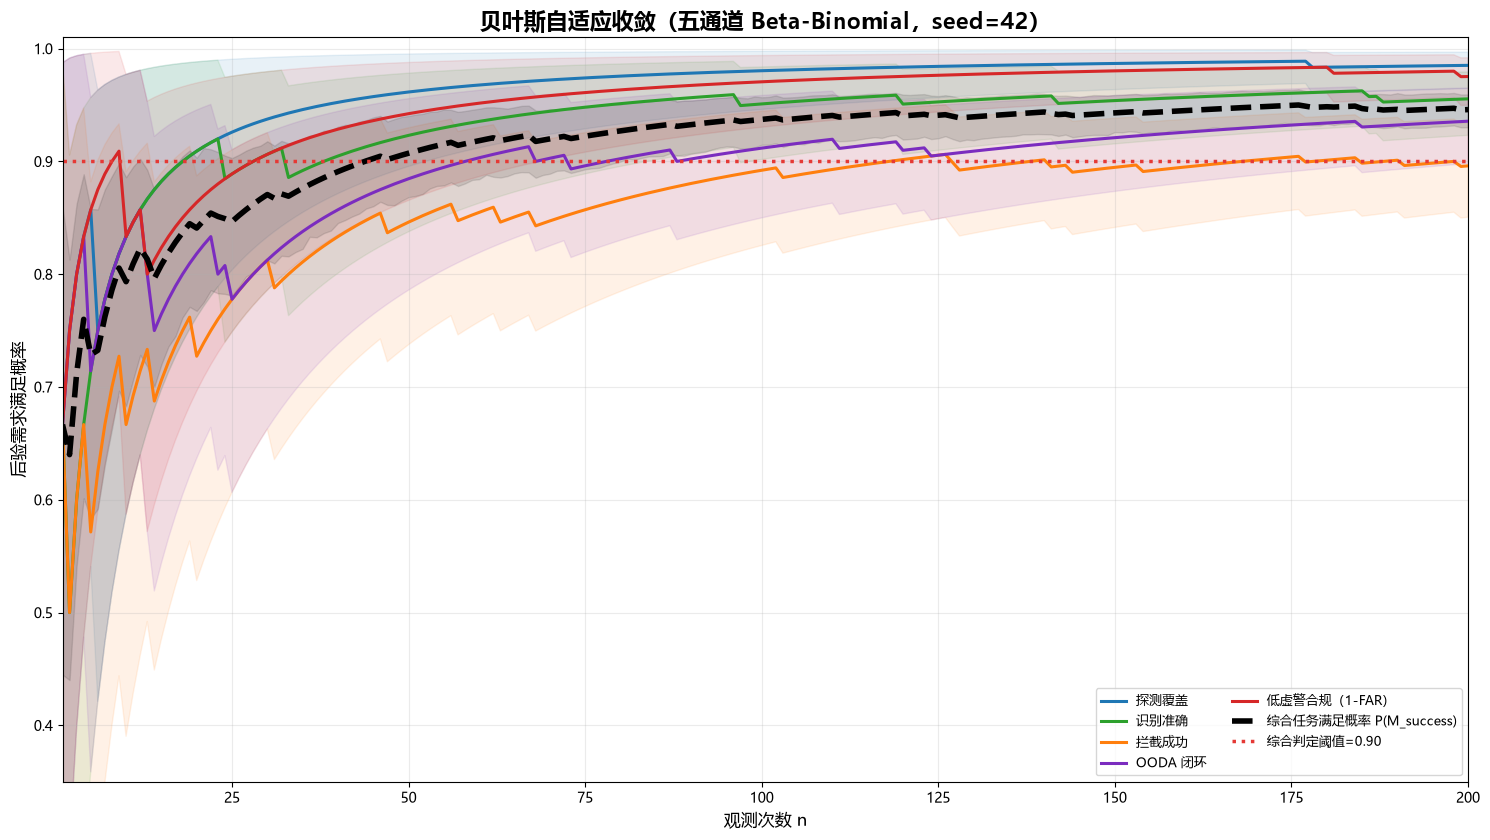

In [4]:
colors = {
    'detection': '#1F77B4',
    'identification': '#2CA02C',
    'interception': '#FF7F0E',
    'ooda_closure': '#7B2CBF',
    'false_alarm_compliance': '#D62728',
}

fig, ax = plt.subplots(figsize=(15, 8.5))
for channel in CHANNELS:
    key = channel.key
    color = colors[key]
    ax.fill_between(
        flywheel.steps,
        flywheel.credible_low[key],
        flywheel.credible_high[key],
        color=color,
        alpha=0.10,
    )
    ax.plot(
        flywheel.steps,
        flywheel.posterior_mean[key],
        color=color,
        lw=2.2,
        label=channel.label_zh,
    )

ax.fill_between(
    flywheel.steps,
    flywheel.combined_low,
    flywheel.combined_high,
    color='black',
    alpha=0.10,
)
ax.plot(
    flywheel.steps,
    flywheel.combined_mean,
    color='black',
    lw=4,
    ls='--',
    label='综合任务满足概率 P(M_success)',
)
ax.axhline(
    COMPOSITE_THRESHOLD,
    color='#E53935',
    lw=2.5,
    ls=':',
    label=f'综合判定阈值={COMPOSITE_THRESHOLD:.2f}',
)
ax.set_xlim(1, flywheel.n_observations)
ax.set_ylim(0.35, 1.01)
ax.set_xlabel('观测次数 n', fontsize=12)
ax.set_ylabel('后验需求满足概率', fontsize=12)
ax.set_title('贝叶斯自适应收敛（五通道 Beta-Binomial，seed=42）', fontsize=16, weight='bold')
ax.grid(alpha=0.25)
ax.legend(loc='lower right', ncol=2, fontsize=9)
plt.tight_layout()
for name in ('fig3_1_bayesian_flywheel.png', 'fig3_1_convergence.png'):
    fig.savefig(OUTPUT_DIR / name, dpi=160, bbox_inches='tight')
plt.show()

In [5]:
posterior_table = pd.DataFrame(flywheel_channel_rows(flywheel))
posterior_table

,通道,指标映射,权重,合成真值,工程门槛,成功观测,总观测,终态后验均值,95%下界,95%上界
0,探测覆盖,DetectionCoverage >= 0.95,0.24,0.972,0.95,198,200,0.985149,0.964520,0.996911
1,识别准确,IdentificationAccuracy >= 0.92,0.20,0.948,0.92,192,200,0.955446,0.923085,0.979324
2,拦截成功,InterceptionSuccessRate >= 0.85,0.24,0.895,0.85,180,200,0.896040,0.850513,0.934154
3,OODA 闭环,P(full-loop latency < 5 s) >= 0.90,0.22,0.935,0.90,188,200,0.935644,0.898036,0.965116
4,低虚警合规（1-FAR）,1 - FalseAlarmRate >= 0.98,0.10,0.986,0.98,196,200,0.975248,0.949833,0.991875


## 3. 1000 次重复实验：收敛与校准

为避免只展示一个有利随机种子，使用另外的主种子执行 1000 次重复实验。收敛定义为综合后验连续 10 个周期不低于 0.90；最终可信区间用独立 Beta 后验加权和的均值/方差近似核验覆盖率。

In [6]:
audit = audit_flywheel_reproducibility(
    n_runs=1000,
    n_observations=200,
    seed=20260811,
)
audit_table = pd.DataFrame([{
    '重复次数': audit.n_runs,
    '合成真值': audit.true_composite,
    '收敛均值': audit.convergence_mean_cycles,
    '收敛P95': audit.convergence_p95_cycles,
    '未收敛率': audit.non_convergence_rate,
    '终态均值': audit.final_composite_mean,
    '95%CI覆盖率': audit.credible_interval_coverage_95,
    '后验RMSE': audit.posterior_rmse,
}])
audit_table

,重复次数,合成真值,收敛均值,收敛P95,未收敛率,终态均值,95%CI覆盖率,后验RMSE
0,1000,0.94198,23.805,50.0,0.0,0.937353,0.937,0.008894


## 4. 与固定规则模型的公平 AUC 对照

两个模型使用完全相同的 Mission 案例、五通道观测与观测次数：

- 贝叶斯模型：计算每个潜在满足率超过对应工程门槛的后验概率，并用任务权重做几何聚合；
- 固定规则模型：对同一经验满足率逐通道执行预声明硬阈值，以通过权重之和作为 ROC 分数；
- 正负类门槛附近保留 0.04 灰区，灰区案例不被强行贴标签；
- 不使用未来数据，不给贝叶斯模型更多样本，也不以测试标签调参。

In [7]:
comparison = evaluate_fixed_rule_baseline(
    n_cases_per_seed=800,
    observations_per_channel=30,
    n_seeds=20,
    seed=20260810,
)
comparison_table = pd.DataFrame([
    {
        '模型': '五通道 Beta 后验',
        'AUC': comparison.bayesian_auc,
        '平衡阈值': comparison.bayesian_threshold,
        'FPR': comparison.bayesian_fpr,
        'FNR': comparison.bayesian_fnr,
    },
    {
        '模型': '固定硬规则',
        'AUC': comparison.fixed_rule_auc,
        '平衡阈值': comparison.fixed_rule_threshold,
        'FPR': comparison.fixed_rule_fpr,
        'FNR': comparison.fixed_rule_fnr,
    },
])
print(f'配对种子 ΔAUC 均值 = {comparison.paired_seed_auc_delta_mean:.4f}')
print(f'配对种子 ΔAUC 95% CI = [{comparison.paired_seed_auc_delta_ci95[0]:.4f}, {comparison.paired_seed_auc_delta_ci95[1]:.4f}]')
comparison_table

配对种子 ΔAUC 均值 = 0.0992
配对种子 ΔAUC 95% CI = [0.0949, 0.1035]


,模型,AUC,平衡阈值,FPR,FNR
0,五通道 Beta 后验,0.967892,0.3743,0.096500,0.081750
1,固定硬规则,0.868806,0.7600,0.296875,0.143625


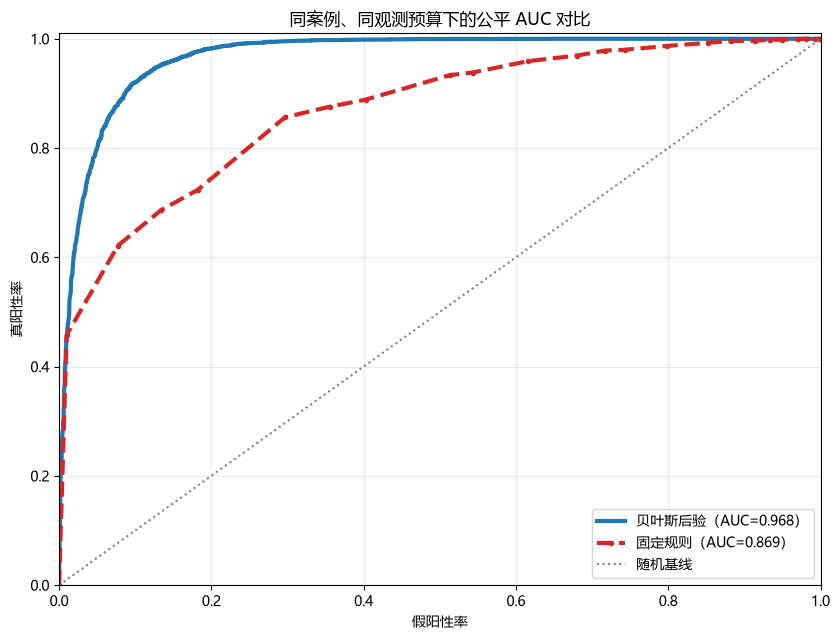

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.plot(
    comparison.bayesian_roc['fpr'],
    comparison.bayesian_roc['tpr'],
    color='#1F77B4',
    lw=3,
    label=f'贝叶斯后验（AUC={comparison.bayesian_auc:.3f}）',
)
ax.plot(
    comparison.fixed_rule_roc['fpr'],
    comparison.fixed_rule_roc['tpr'],
    color='#D62728',
    lw=3,
    ls='--',
    marker='o',
    ms=3,
    label=f'固定规则（AUC={comparison.fixed_rule_auc:.3f}）',
)
ax.plot([0, 1], [0, 1], color='gray', ls=':', label='随机基线')
ax.set(xlabel='假阳性率', ylabel='真阳性率', xlim=(0, 1), ylim=(0, 1.01))
ax.set_title('同案例、同观测预算下的公平 AUC 对比')
ax.grid(alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig3_5_roc.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. 观测预算敏感性

In [9]:
budget_rows = []
for budget in [10, 20, 30, 50, 80]:
    result = evaluate_fixed_rule_baseline(
        n_cases_per_seed=400,
        observations_per_channel=budget,
        n_seeds=8,
        seed=20260810,
    )
    budget_rows.append({
        '每通道观测数': budget,
        '贝叶斯AUC': result.bayesian_auc,
        '固定规则AUC': result.fixed_rule_auc,
        'ΔAUC': result.auc_delta,
    })
budget_table = pd.DataFrame(budget_rows)
budget_table

,每通道观测数,贝叶斯AUC,固定规则AUC,ΔAUC
0,10,0.885757,0.806231,0.079526
1,20,0.943416,0.873938,0.069478
2,30,0.968632,0.874390,0.094242
3,50,0.988532,0.909409,0.079124
4,80,0.995168,0.928151,0.067018


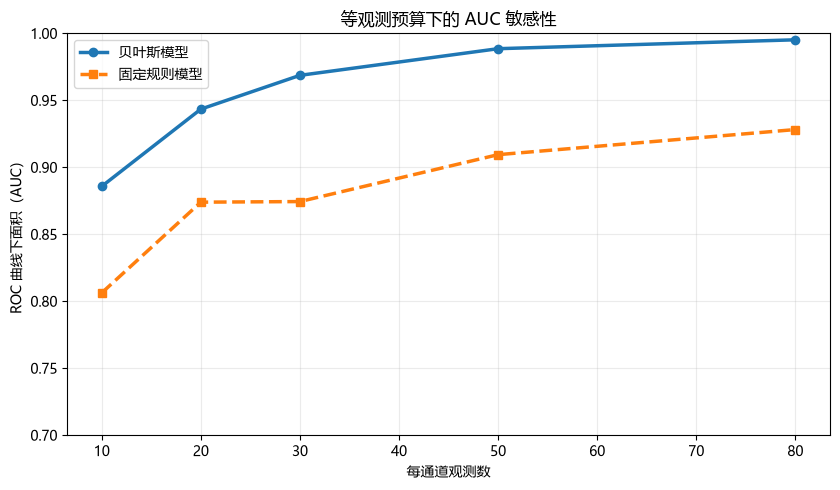

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(budget_table['每通道观测数'], budget_table['贝叶斯AUC'], 'o-', lw=2.5, label='贝叶斯模型')
ax.plot(budget_table['每通道观测数'], budget_table['固定规则AUC'], 's--', lw=2.5, label='固定规则模型')
ax.set_xlabel('每通道观测数')
ax.set_ylabel('ROC 曲线下面积（AUC）')
ax.set_ylim(0.70, 1.00)
ax.set_title('等观测预算下的 AUC 敏感性')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig3_6_budget_auc.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. 本体拓扑条件化先验与反事实重构

主实验仍采用统一 Beta(1,1) 先验。本节作为补充敏感性实验，将 `Equipment → implements → TechnicalCapability → produces → EffectMetric` 路径与装备健康度映射到先验均值。三种情景共享完全相同的 12 次观测，因此分数变化只来自本体路径和健康状态。该分数是合成任务合规度，不是物理毁伤概率。

In [11]:
counterfactual = evaluate_ontology_conditioned_counterfactual(
    PROJECT_ROOT / '03_源码' / '本体模型' / 'cuas-ontology.ttl',
    PROJECT_ROOT / '03_源码' / '本体模型' / 'cuas-data-valid.ttl',
    n_observations=12,
    seed=20260812,
)
counterfactual_table = pd.DataFrame([
    {
        '情景': item['scenario'],
        '任务合规后验分数': item['mission_compliance_score'],
        '本体路径数': len(item['graph_paths']),
    }
    for item in counterfactual['scenarios']
])
counterfactual_table

,情景,任务合规后验分数,本体路径数
0,名义状态,0.673743,5
1,主雷达失效,0.041481,5
2,本体重构至射频/光电备份,0.638454,5


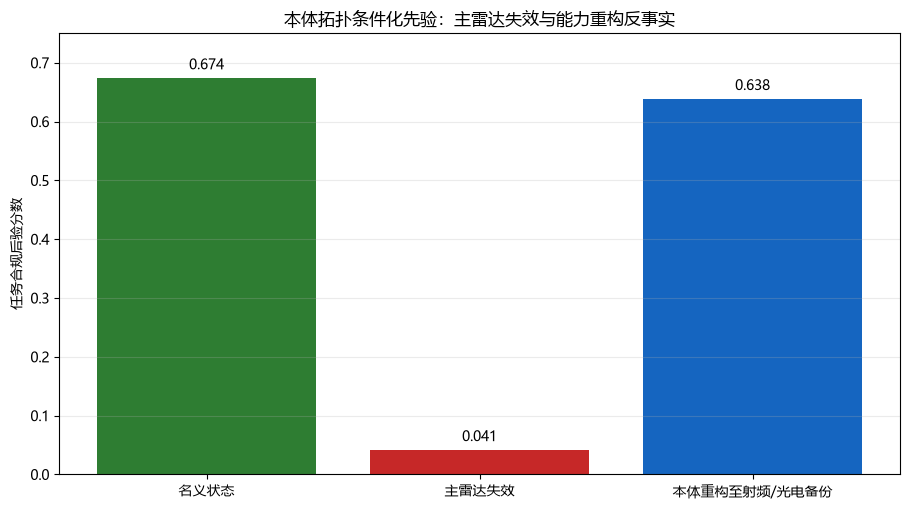

共享观测: {'detection': 12, 'identification': 10, 'interception': 12, 'ooda_closure': 11, 'false_alarm_compliance': 12}
反事实检查: {'radar_failure_reduces_score': True, 'reconfiguration_recovers_score': True, 'paths_derived_from_graph': True}


In [12]:
fig, ax = plt.subplots(figsize=(9.2, 5.2))
bars = ax.bar(
    counterfactual_table['情景'],
    counterfactual_table['任务合规后验分数'],
    color=['#2E7D32', '#C62828', '#1565C0'],
)
ax.set_ylabel('任务合规后验分数')
ax.set_ylim(0, 0.75)
ax.set_title('本体拓扑条件化先验：主雷达失效与能力重构反事实')
ax.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, counterfactual_table['任务合规后验分数']):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.015, f'{value:.3f}', ha='center')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig3_7_ontology_counterfactual.png', dpi=160, bbox_inches='tight')
plt.show()
print('共享观测:', counterfactual['shared_successes'])
print('反事实检查:', counterfactual['checks'])

## 7. 自动验收与机器可读指标

In [13]:
checks = {
    'weights_sum_to_one': bool(np.isclose(weight_sum, 1.0)),
    'seed42_composite_reaches_0_90': bool(flywheel.final_composite >= COMPOSITE_THRESHOLD),
    'all_runs_converged': bool(audit.non_convergence_rate == 0.0),
    'coverage_90_to_99_pct': bool(0.90 <= audit.credible_interval_coverage_95 <= 0.99),
    'posterior_rmse_le_0_03': bool(audit.posterior_rmse <= 0.03),
    'bayesian_auc_ge_0_85': bool(comparison.bayesian_auc >= 0.85),
    'bayesian_fpr_le_0_10': bool(comparison.bayesian_fpr <= 0.10),
    'bayesian_fnr_le_0_10': bool(comparison.bayesian_fnr <= 0.10),
    'paired_delta_ci_above_zero': bool(comparison.paired_seed_auc_delta_ci95[0] > 0.0),
    'ontology_prior_failure_reduces_score': bool(counterfactual['checks']['radar_failure_reduces_score']),
    'ontology_prior_reconfiguration_recovers_score': bool(counterfactual['checks']['reconfiguration_recovers_score']),
    'ontology_paths_derived_from_graph': bool(counterfactual['checks']['paths_derived_from_graph']),
}
assert all(checks.values()), checks

metrics_payload = {
    'schema_version': 2,
    'scope': 'synthetic_five_channel_beta_binomial_flywheel',
    'not_field_test': True,
    'random_seeds': {
        'flywheel': 42,
        'reproducibility': audit.seed,
        'auc_comparison': comparison.seed,
    },
    'weight_sum': float(weight_sum),
    'feedback_cycles_per_run': flywheel.n_observations,
    'monte_carlo_runs': audit.n_runs,
    'convergence_definition': {
        'composite_threshold': COMPOSITE_THRESHOLD,
        'sustained_cycles': 10,
    },
    'seed42_final_composite': flywheel.final_composite,
    'seed42_final_ci95': list(flywheel.final_composite_interval),
    'seed42_sustained_convergence_cycle': flywheel.sustained_threshold_crossing,
    'convergence_mean_cycles': audit.convergence_mean_cycles,
    'convergence_std_cycles': audit.convergence_std_cycles,
    'convergence_p95_cycles': audit.convergence_p95_cycles,
    'non_convergence_rate': audit.non_convergence_rate,
    'final_posterior_mean': audit.final_composite_mean,
    'final_posterior_std': audit.final_composite_std,
    'effective_truth': audit.true_composite,
    'credible_interval_coverage_95': audit.credible_interval_coverage_95,
    'posterior_rmse': audit.posterior_rmse,
    'auc': comparison.bayesian_auc,
    'fixed_rule_auc': comparison.fixed_rule_auc,
    'auc_delta': comparison.auc_delta,
    'paired_auc_delta_ci95': list(comparison.paired_seed_auc_delta_ci95),
    'observations_per_channel_for_auc': comparison.observations_per_channel,
    'auc_cases_total': int(len(comparison.labels)),
    'decision_threshold': comparison.bayesian_threshold,
    'fpr': comparison.bayesian_fpr,
    'fnr': comparison.bayesian_fnr,
    'fixed_rule_threshold': comparison.fixed_rule_threshold,
    'fixed_rule_fpr': comparison.fixed_rule_fpr,
    'fixed_rule_fnr': comparison.fixed_rule_fnr,
    'gray_zone_margin': 0.04,
    'ontology_conditioned_counterfactual': counterfactual,
    'channels': flywheel_channel_rows(flywheel),
    'checks': checks,
}
metrics_path = OUTPUT_DIR / 'metrics_notebook_03.json'
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print(json.dumps(checks, ensure_ascii=False, indent=2))
print('机器可读指标:', metrics_path)

{
  "weights_sum_to_one": true,
  "seed42_composite_reaches_0_90": true,
  "all_runs_converged": true,
  "coverage_90_to_99_pct": true,
  "posterior_rmse_le_0_03": true,
  "bayesian_auc_ge_0_85": true,
  "bayesian_fpr_le_0_10": true,
  "bayesian_fnr_le_0_10": true,
  "paired_delta_ci_above_zero": true,
  "ontology_prior_failure_reduces_score": true,
  "ontology_prior_reconfiguration_recovers_score": true,
  "ontology_paths_derived_from_graph": true
}
机器可读指标: D:\Downloads\反无人机体系\智信2026_新概念反无_完整项目包\05_Notebook与数据\验证输出\metrics_notebook_03.json


## 8. 结论与证据边界

1. 已复现五通道 Beta-Binomial 收敛图，并修复旧版综合权重和为 0.50 的错误；
2. 五条后验、可信区间、综合反馈曲线和工程门槛均由执行数据生成；
3. AUC 对照纳入固定硬规则模型，两个模型严格共享观测预算；
4. 补充反事实实验证明本体路径与装备健康度可改变先验，并能表达“主雷达失效—备份能力重构”；
5. 本实验说明不确定性建模与反馈聚合在该合成基准上的区分优势，不能表述为物理拦截率提升或机场实测结论。